# Get surrounding bboxes before crossing is done
* meaning we drop everything after the crossing event 
* check adjust_bbox_size_include_crossing.ipynb

In [1]:
from utils.data_loader import load_dict

/data/home/acw607/stacking/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Get new keypoints from mmpose
* pro: multiple keypoints, cons: could have no keypoints (to check)
* to do: record keypoints and image paths
*       mask surrounding bbox


In [2]:
import json
import numpy as np
df = load_dict('bbox_beh_include_crossing_new.json')

In [3]:
def find_center(bbox):
    x1, y1, x2, y2 = bbox[0], bbox[1], bbox[2], bbox[3]
    return (x1+x2)/2, (y1+y2)/2

In [4]:
def find_keypoints_center(keypoints):
    keypoints = np.array(keypoints)
    min_x, max_x=min(keypoints[:,0]), max(keypoints[:,0])
    min_y, max_y=min(keypoints[:,1]), max(keypoints[:,1])
    center = (min_x+max_x)/2, (min_y+max_y)/2
    return center

In [5]:
def distance(keypoints_center, shift_bbox_center):
    x1, y1 = keypoints_center[0], keypoints_center[1]
    x2, y2 = shift_bbox_center[0], shift_bbox_center[1]
    return (abs(x1-x2)**2+(abs(y1-y2)**2))**(1/2)

In [6]:
def predict_allkeypoints(inferencer, img_path):
    # creating a prediction generator when given input
    result_generator = inferencer(img_path, show=False)
    result = next(result_generator)
    result = result['predictions'][0]#a list of multiple keypoint dict
    people_keypoints = [dic['keypoints'] for dic in result]
    return people_keypoints

In [11]:
# import sys
# from mmpose.apis import MMPoseInferencer

# def find_true_keypoints(inferencer, img_path,df):
#     people_keypoints = predict_allkeypoints(inferencer, img_path)
#     shift_bbox_center_li = []
#     print(len(people_keypoints))
#     dist_li = []
    
#     f_img = img_path.split('/')[-1]
#     example = df[f_img]
#     if len(people_keypoints)>1:
#         for person_keys in people_keypoints:
#             a, b = example['surounding_bbox'][0], example['surounding_bbox'][1]# x-> shift a, y->shift b
#             bbox_center = find_center(example['ped_bbox'])#find raw pedbbox center
#             keypoints_center = find_keypoints_center(person_keys)#find keypoint center
#             shift_bbox_center = bbox_center[0]-a, bbox_center[1]-b#shift pedbbox center
#             shift_bbox_center_li.append(shift_bbox_center)
#             dist = distance(keypoints_center, shift_bbox_center)
#             dist_li.append(dist)
#         return shift_bbox_center_li[np.argmin(dist_li)], people_keypoints[np.argmin(dist_li)]
    
#     elif len(people_keypoints)==1:
        
#         return shift_bbox_center, people_keypoints[0]
#     else:
#         sys.exit('something wrong, should have at least a person keypoints')

In [18]:
import sys
from mmpose.apis import MMPoseInferencer
def find_true_keypoints(inferencer, img_path,df):
    people_keypoints = predict_allkeypoints(inferencer, img_path)
#     print(len(people_keypoints))
    dist_li = []
    
    f_img = img_path.split('/')[-1]
    example = df[f_img]
    """
    find the surrounding bbox and the center of the ped_bbox we're looking for, 
    only 1 surrounding bbox and 1 ped_bbox available
    """
    a, b = example['surounding_bbox'][0], example['surounding_bbox'][1]# x-> shift a, y->shift b
    bbox_center = find_center(example['ped_bbox'])#find raw pedbbox center
    shift_bbox_center = bbox_center[0]-a, bbox_center[1]-b
    
    if len(people_keypoints)>1:
        for person_keys in people_keypoints:
            keypoints_center = find_keypoints_center(person_keys)#find keypoint center
            dist = distance(keypoints_center, shift_bbox_center)
            print(dist)
            dist_li.append(dist)
                
        return shift_bbox_center, people_keypoints[np.argmin(dist_li)]
    
    elif len(people_keypoints)==1:
        return shift_bbox_center, people_keypoints[0]
        
    else:
        sys.exit('something wrong, should have at least a person keypoints')

In [16]:
from PIL import Image
import matplotlib.pyplot as plt
def plot_keys_and_centre(img_path, real_keys, shift_bbox_center):
    f = img_path.split('/')[-1]
    img = np.asarray(Image.open(img_path))
    imgplot = plt.imshow(img)
    shift_x, shift_y = shift_bbox_center[0], shift_bbox_center[1]
    keys = ['nose', 'left_eye', 'right_eye', 'left_ear', 'right_ear', 'left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow', 'left_wrist', 'right_wrist', 'left_hip', 'right_hip', 'left_knee', 'right_knee', 'left_ankle', 'right_ankle']
    for i, k in enumerate(real_keys):
        plt.plot(k[0],k[1], 'y*')
        if keys[i] == 'nose' or keys[i]== 'right_elbow':
            plt.text(k[0],k[1]+5, str(keys[i]) , fontsize = 10, color='r')

    plt.plot(shift_x, shift_y, 'r*')    

Loads checkpoint by http backend from path: https://download.openmmlab.com/mmpose/v1/projects/rtmposev1/rtmpose-m_simcc-body7_pt-body7_420e-256x192-e48f03d0_20230504.pth
Loads checkpoint by http backend from path: https://download.openmmlab.com/mmpose/v1/projects/rtmposev1/rtmdet_m_8xb32-100e_coco-obj365-person-235e8209.pth
2.5414914340798846
18.072329990178392


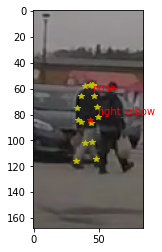

In [19]:
img_path = 'examples/0_1_2_560_c0.png'
inferencer = MMPoseInferencer('human', device='cuda:0')# instantiate the inferencer using the model alias
shift_bbox_center, real_keys = find_true_keypoints(inferencer, img_path,df)
plot_keys_and_centre(img_path, real_keys, shift_bbox_center)

Loads checkpoint by http backend from path: https://download.openmmlab.com/mmpose/v1/projects/rtmposev1/rtmpose-m_simcc-body7_pt-body7_420e-256x192-e48f03d0_20230504.pth
Loads checkpoint by http backend from path: https://download.openmmlab.com/mmpose/v1/projects/rtmposev1/rtmdet_m_8xb32-100e_coco-obj365-person-235e8209.pth


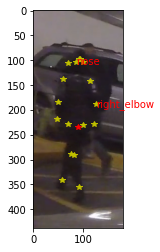

In [20]:
img_path = 'examples/0_2_6b_191_c0.png'
inferencer = MMPoseInferencer('human', device='cuda:0')# instantiate the inferencer using the model alias
shift_bbox_center, real_keys = find_true_keypoints(inferencer, img_path,df)
plot_keys_and_centre(img_path, real_keys, shift_bbox_center)

In [16]:
# %matplotlib inline
# import matplotlib.pyplot as plt
# from PIL import Image
# img_path = 'examples/0_2_6b_191_c0.png'
# img = np.asarray(Image.open('output/visualizations/0_2_6b_191_c0.png'))
# imgplot = plt.imshow(img)
# example = df['0_2_6b_191_c0.png']
# bbox_center = find_center(example['ped_bbox'])
# a, b = example['surounding_bbox'][0], example['surounding_bbox'][1]
# shift_x, shift_y = bbox_center[0]-a, bbox_center[1]-b
# real_keys = find_true_keypoints(inferencer, img_path,df)

# keys = ['nose', 'left_eye', 'right_eye', 'left_ear', 'right_ear', 'left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow', 'left_wrist', 'right_wrist', 'left_hip', 'right_hip', 'left_knee', 'right_knee', 'left_ankle', 'right_ankle']
# for i, k in enumerate(real_keys):
# #     plt.plot(k[0],k[1], 'y*')
#     if keys[i] == 'nose' or keys[i]== 'right_elbow':
#         plt.text(k[0],k[1]+5, str(keys[i]) , fontsize = 10, color='r')
    
# plt.plot(shift_x, shift_y, 'r*')

In [17]:
import io
import sys
import os
from tqdm import tqdm
df = load_dict('bbox_beh_include_crossing_new.json')
root = 'vid_images_surroundings_beh/'
vids = os.listdir(root)
if '.DS_Store' in vids:
    vids.remove('.DS_Store')
inferencer = MMPoseInferencer('human', device='cuda:0')
for i in tqdm(range(len(vids))): #tqdm show progress bar
    vid = vids[i]
    cases = ['pos', 'neg']
    for case in cases:
        img_list = os.listdir(root+vid+'/'+case+'/')
        for img in img_list:
            img_path = root+vid+'/'+case+'/'+img
            text_trap = io.StringIO()#silent output
            sys.stdout = text_trap#silent output
            _, keypoints = find_true_keypoints(inferencer,img_path,df)       
            sys.stdout = sys.__stdout__#silent output
            df[img]['keypoints'] = keypoints

with open("bbox_beh_include_crossing_withkeypoints_update.json", "w") as outfile:
    json.dump(df, outfile)
    
    
    

Loads checkpoint by http backend from path: https://download.openmmlab.com/mmpose/v1/projects/rtmposev1/rtmpose-m_simcc-body7_pt-body7_420e-256x192-e48f03d0_20230504.pth
Loads checkpoint by http backend from path: https://download.openmmlab.com/mmpose/v1/projects/rtmposev1/rtmdet_m_8xb32-100e_coco-obj365-person-235e8209.pth


100%|██████████| 346/346 [2:50:36<00:00, 29.58s/it]   


Loads checkpoint by http backend from path: https://download.openmmlab.com/mmpose/v1/projects/rtmposev1/rtmpose-m_simcc-body7_pt-body7_420e-256x192-e48f03d0_20230504.pth
Loads checkpoint by http backend from path: https://download.openmmlab.com/mmpose/v1/projects/rtmposev1/rtmdet_m_8xb32-100e_coco-obj365-person-235e8209.pth
Loads checkpoint by http backend from path: https://download.openmmlab.com/mmpose/v1/projects/rtmposev1/rtmpose-m_simcc-body7_pt-body7_420e-256x192-e48f03d0_20230504.pth
Loads checkpoint by http backend from path: https://download.openmmlab.com/mmpose/v1/projects/rtmposev1/rtmdet_m_8xb32-100e_coco-obj365-person-235e8209.pth
Loads checkpoint by http backend from path: https://download.openmmlab.com/mmpose/v1/projects/rtmposev1/rtmpose-m_simcc-body7_pt-body7_420e-256x192-e48f03d0_20230504.pth
Loads checkpoint by http backend from path: https://download.openmmlab.com/mmpose/v1/projects/rtmposev1/rtmdet_m_8xb32-100e_coco-obj365-person-235e8209.pth
1
Loads checkpoint by 

In [18]:
df = load_dict("bbox_beh_include_crossing_withkeypoints_update.json")

In [19]:
list(df.keys())[0]

'0_2_5b_18_c0.png'

In [20]:
df['0_2_5b_18_c0.png'].keys()

dict_keys(['ped_bbox', 'surounding_bbox', 'keypoints'])

In [21]:
# restructure df
# from
"""
{'01.png': {'ped_bbox':[], 'surrounding_bbox':[], 'keypoints':[]}}
"""
# to
'''
{
    'pos':{'pedID1':{'imgs':[], 'keypoints':{'nose':[], 'left_eye':[], ...etc}}
    'neg': like above
}
'''

"\n{\n    'pos':{'pedID1':{'imgs':[], 'keypoints':{'nose':[], 'left_eye':[], ...etc}}\n    'neg': like above\n}\n"

In [22]:
import os
from tqdm import tqdm
from collections import defaultdict
root = 'vid_images_surroundings_beh/'
vids = os.listdir(root)
if '.DS_Store' in vids:
    vids.remove('.DS_Store')

labels_df = {'pos':{}, 'neg':{}}
keys = ['nose', 'left_eye', 'right_eye', 'left_ear', 'right_ear', 'left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow', 'left_wrist', 'right_wrist', 'left_hip', 'right_hip', 'left_knee', 'right_knee', 'left_ankle', 'right_ankle']
for i in tqdm(range(len(vids))): #tqdm show progress bar
    vid = vids[i]
    cases = ['pos', 'neg']
    for case in cases:
        img_list = os.listdir(root+vid+'/'+case+'/')
        for img in img_list:
            img_path = root+vid+'/'+case+'/'+img
            eles = img.split('_')
            ped = eles[0]+'_'+eles[1]+'_'+eles[2]
            
            if not ped in list(labels_df[case].keys()):
                labels_df[case][ped] = {'imgs':[], 'keypoints':{}}
#                 wrong: labels_df[case][ped]['keypoints'] = dict.fromkeys(keys, [])
                labels_df[case][ped]['keypoints'] = defaultdict(list)
            
            labels_df[case][ped]['imgs'].append(img_path)

            for i, key_coord in enumerate(df[img]['keypoints']):
#                 print(f'{keys[i]} with {key_coord}')
                labels_df[case][ped]['keypoints'][keys[i]].append(key_coord)
                

100%|██████████| 346/346 [00:06<00:00, 53.13it/s]


In [23]:
labels_df[case][ped]['keypoints'][keys[0]][0]

[64.62248229980469, 65.98503112792969]

In [24]:
labels_df[case][ped]['keypoints'][keys[1]][0]

[66.34213256835938, 62.54573059082031]

# sort keypoints 
sort keypoints with correct frame order

In [25]:
def find_frame(img_path):
    f = img_path.split('/')[-1]
    frame = f.split('_')[3]
    return frame

In [26]:
for case in list(labels_df.keys()):
    pedIDs = labels_df[case].keys()
    
    for ID in pedIDs:
        img_list = labels_df[case][ID]['imgs']
        Y= img_list.copy()
        for k in list(labels_df[case][ID]['keypoints'].keys()):
            X= labels_df[case][ID]['keypoints'][k].copy()
            new_X = [x for _, x in sorted(zip(Y, X), key=lambda pair: int(find_frame(pair[0])))]
            labels_df[case][ID]['keypoints'][k] = new_X
        new_Y = [y for y, _ in sorted(zip(Y, X), key=lambda pair: int(find_frame(pair[0])))]
        labels_df[case][ID]['imgs'] = new_Y
    
        
    

In [27]:
labels_df[case][ID]['keypoints']['nose'][2]

[61.59306335449219, 24.870084762573242]

In [28]:
labels_df[case][ID]['keypoints']['right_eye'][2]

[60.78353500366211, 24.22245979309082]

In [1]:
import json
from utils.data_loader import load_dict
labels_df = load_dict("bbox_beh_include_crossing_withkeypoints_sorted_updated.json")

/data/home/acw607/stacking/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


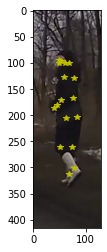

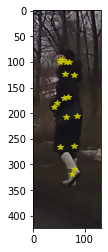

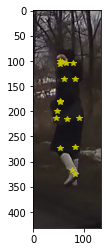

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
keys = ['nose', 'left_eye', 'right_eye', 'left_ear', 'right_ear', 'left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow', 'left_wrist', 'right_wrist', 'left_hip', 'right_hip', 'left_knee', 'right_knee', 'left_ankle', 'right_ankle']
case = 'neg'
ID = '0_253_1974b'

for i in range(156, 159):
    img_path = labels_df[case][ID]['imgs'][i]
    img = np.asarray(Image.open(img_path))
    imgplot = plt.imshow(img)
    for k in keys:        
        x, y = labels_df[case][ID]['keypoints'][k][i][0], labels_df[case][ID]['keypoints'][k][i][1]
        plt.plot(x, y, 'y*')
    plt.show()


In [30]:
import json
with open("bbox_beh_include_crossing_withkeypoints_sorted_updated.json", "w") as outfile:
    json.dump(labels_df, outfile)

In [31]:
len(labels_df['pos'][ID]['imgs']) == len(labels_df['pos'][ID]['keypoints']['nose'])

True

In [1]:
import json
from utils.data_loader import load_dict
labels_df = load_dict("bbox_beh_include_crossing_withkeypoints_sorted_updated.json")
labels_df_2 = load_dict("bbox_beh_include_crossing_withkeypoints_sorted.json")

/data/home/acw607/stacking/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [18]:
labels_df == labels_df_2

False

In [41]:
def find_true_keypoints(inferencer, img_path,df):
    people_keypoints = predict_allkeypoints(inferencer, img_path)
    dist_li = []
    
    f_img = img_path.split('/')[-1]
    example = df[f_img]
    """
    find the surrounding bbox and the center of the ped_bbox we're looking for, 
    only 1 surrounding bbox and 1 ped_bbox available
    """
    a, b = example['surounding_bbox'][0], example['surounding_bbox'][1]# x-> shift a, y->shift b
    bbox_center = find_center(example['ped_bbox'])#find raw pedbbox center
    shift_bbox_center = bbox_center[0]-a, bbox_center[1]-b
    if len(people_keypoints)>1:
        for person_keys in people_keypoints:
            keypoints_center = find_keypoints_center(person_keys)#find keypoint center
            dist = distance(keypoints_center, shift_bbox_center)
            dist_li.append(dist)
                
        return shift_bbox_center, people_keypoints[np.argmin(dist_li)]
    elif len(people_keypoints)==1:
        return shift_bbox_center, people_keypoints[0]
        
    else:
        sys.exit('something wrong, should have at least a person keypoints')

Loads checkpoint by http backend from path: https://download.openmmlab.com/mmpose/v1/projects/rtmposev1/rtmpose-m_simcc-body7_pt-body7_420e-256x192-e48f03d0_20230504.pth
Loads checkpoint by http backend from path: https://download.openmmlab.com/mmpose/v1/projects/rtmposev1/rtmdet_m_8xb32-100e_coco-obj365-person-235e8209.pth
1


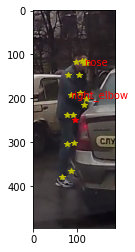

In [19]:
case = 'neg'
ID = '0_246_1894b'
img_path = labels_df[case][ID]['imgs'][-10]
inferencer = MMPoseInferencer('human', device='cuda:0')# instantiate the inferencer using the model alias
# people_keypoints = predict_allkeypoints(inferencer, img_path)
shift_bbox_center, real_keys= find_true_keypoints(inferencer, img_path,df)
plot_keys_and_centre(img_path, real_keys, shift_bbox_center)

In [6]:
labels_df['pos']['0_27_119b'].keys()

dict_keys(['imgs', 'keypoints'])

In [11]:
labels_df = load_dict("bbox_beh_include_crossing_withkeypoints_sorted_updated.json")
labels_df_2 = load_dict("bbox_beh_include_crossing_withkeypoints_sorted.json")

In [7]:
def find_shift_bbox(example):
    a, b = example['surounding_bbox'][0], example['surounding_bbox'][1]# x-> shift a, y->shift b
    x1, y1, x2, y2 = example['ped_bbox']#find raw pedbbox center
    shift_bbox = x1-a, y1-b, x2-a, y2-b
    return shift_bbox

In [13]:
def stackback_keypoints(case, ID, labels_df, frame_idx):
    keys = ['nose', 'left_eye', 'right_eye', 'left_ear', 'right_ear', 'left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow', 'left_wrist', 'right_wrist', 'left_hip', 'right_hip', 'left_knee', 'right_knee', 'left_ankle', 'right_ankle']
    keys_coords = []
    for k in keys:
        a_key = labels_df[case][ID]['keypoints'][k][frame_idx]
        keys_coords.append(a_key)
    return keys_coords

In [21]:
def count_legit_keypoints(df, labels_df):
    cases = ['pos', 'neg']
    correct_count = 0
    wrong_count = 0
    total_imgs = 0
    for case in cases:
        IDs = labels_df[case].keys()
        for ID in IDs:
            imgs = labels_df[case][ID]['imgs']
            for i, img in enumerate(imgs):
                total_imgs+=1
                f_img = img.split('/')[-1]
                example = df[f_img]
                x1, y1, x2, y2 = find_shift_bbox(example)#
                keys_coords=stackback_keypoints(case, ID, labels_df, frame_idx=i)
                key_center_x, key_center_y =  find_keypoints_center(keys_coords)
                if x2>=key_center_x and x1<=key_center_x and y2>=key_center_y and y1<=key_center_y:
                    correct_count+=1
                else:
                    wrong_count+=1
    print('correct: {0}'.format(correct_count))
    print('wrong: {0}'.format(wrong_count))
    print('total: {0}'.format(total_imgs))
            

In [22]:
print('updated_keypoints')
count_legit_keypoints(df, labels_df)

updated_keypoints
correct: 129736
wrong: 2964
total: 132700


In [18]:
print('old_keypoints')
count_legit_keypoints(df, labels_df_2)

old_keypoints
correct: 122025
wrong: 10675
total: 132700


In [19]:
labels_df_3 = load_dict("all_labels_beh-Copy1.json")

In [23]:
count_legit_keypoints(df, labels_df_3)

correct: 0
wrong: 0
total: 54792


In [35]:
def count_legit_keypoints(df, labels_df):
    cases = ['pos', 'neg']
    correct_count = 0
    wrong_count = 0
    total_imgs = 0
    for case in cases:
        try:
            IDs = labels_df[case].keys()
            for ID in IDs:
                imgs = labels_df[case][ID]['imgs']
                for i, img in enumerate(imgs):
                    total_imgs+=1
                    f_img = img.split('/')[-1]
                    f_img = f_img.split('.')[0]
                    f_img = f_img[:-3]+'.png'
                    example = df[f_img]
                    x1, y1, x2, y2 = find_shift_bbox(example)#
                    keys_coords=stackback_keypoints(case, ID, labels_df, frame_idx=i)
                    key_center_x, key_center_y =  find_keypoints_center(keys_coords)
                    if x2>=key_center_x and x1<=key_center_x and y2>=key_center_y and y1<=key_center_y:
                        correct_count+=1
                    else:
                        wrong_count+=1
        except:
            continue

    print('correct: {0}'.format(correct_count))
    print('wrong: {0}'.format(wrong_count))
    print('total: {0}'.format(total_imgs))

In [33]:
count_legit_keypoints(df, labels_df_3)

correct: 46235
wrong: 8557
total: 54792


In [36]:
labels_df_4 = load_dict("all_labels_nobeh-Copy1.json")
count_legit_keypoints(df, labels_df_4)

correct: 96920
wrong: 146193
total: 243113
